# Creating figures for the presentation    

## setup 

In [5]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Your directory with the chunked CSVs
DATA_DIR = Path(r"D:/Coding Projects/AI-in-Drug-Discovery-/presentation_figs/V5_Data")
FIG_DIR  = DATA_DIR / "figures_chunked"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# consistent colors for your classes
CLASS_COLORS = {"inward": "#4CAF50", "occluded": "#FF9800", "outward": "#F44336"}

# Matplotlib styling
plt.rcParams.update({
    "figure.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})
sns.set_context("talk", font_scale=0.9)


## Load CSV

In [6]:
def load_chunked_csvs(folder: Path):
    csvs = sorted(folder.glob("*_chunked_*.csv")) or sorted(folder.glob("*.csv"))
    dfs  = []
    for p in csvs:
        df = pd.read_csv(p)
        # normalize expected columns
        rename = {
            "start_fram": "start_frame",
            "end_fram":   "end_frame",
            "winner_cl":  "winner_class",
        }
        for k,v in rename.items():
            if k in df.columns and v not in df.columns:
                df = df.rename(columns={k:v})
        # enforce types
        keep = ["chunk_id","start_frame","end_frame","max_conf","winner_class","true_class","pred_class"]
        missing = [c for c in keep if c not in df.columns]
        if missing:
            print(f"⚠️ {p.name}: missing columns {missing} — skipping")
            continue
        df["source_file"] = p.stem
        dfs.append(df)
    return dfs

dfs = load_chunked_csvs(DATA_DIR)
print(f"Loaded {len(dfs)} files")
if dfs: dfs[0].head()


Loaded 4 files


## Helper functions 

In [7]:
def title_from_name(name: str):
    # try to pull drug name from filename like cleaned_XYZ_predictions_chunked_20
    parts = name.replace(".csv","").split("_")
    for token in parts:
        if token.isalpha() and len(token) >= 3:
            return token.upper()
    return name

def savefig(fig, path: Path):
    fig.savefig(path, bbox_inches="tight", dpi=300)
    print("✓ Saved", path.name)


## Chunk timeline (true vs predicted bars)

✓ Saved AMP_20_timeline.png


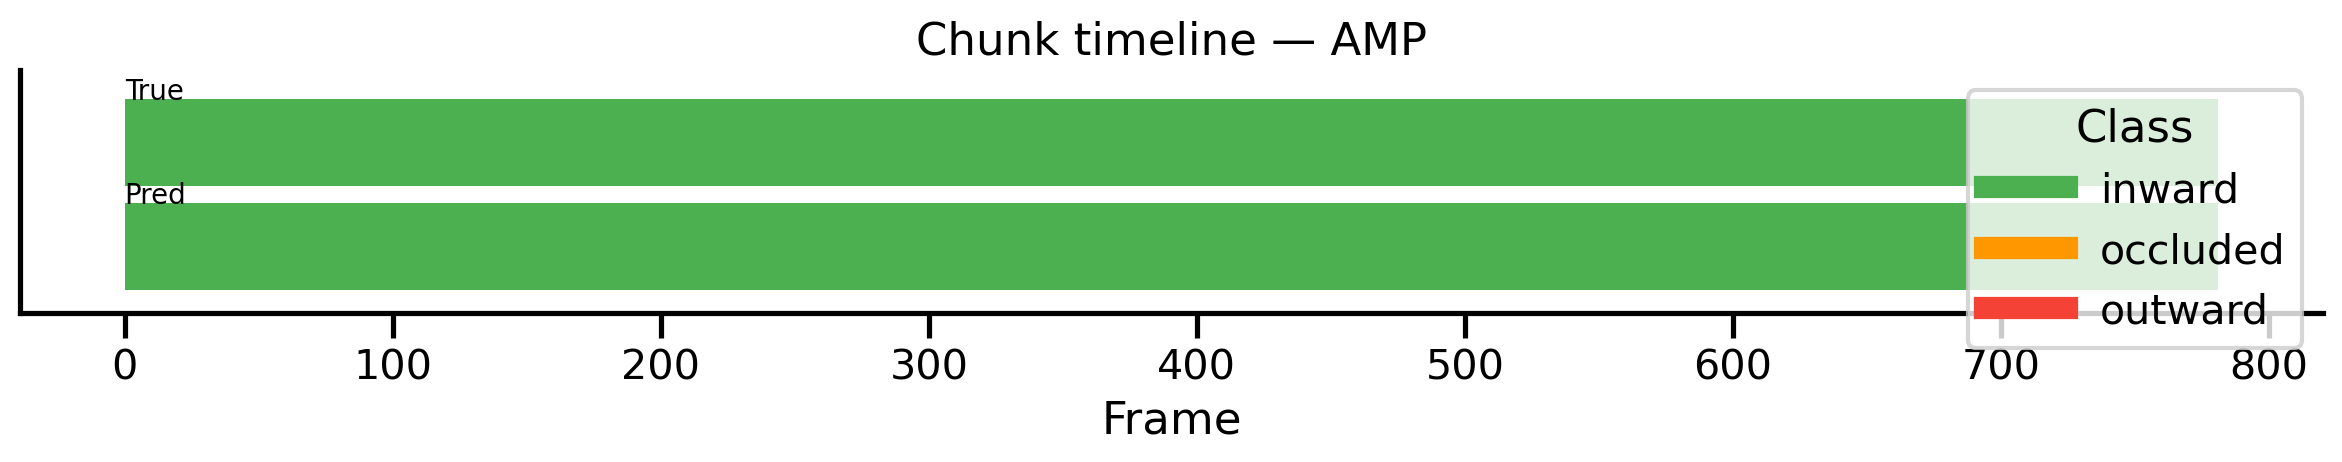

✓ Saved MAPB_20_timeline.png


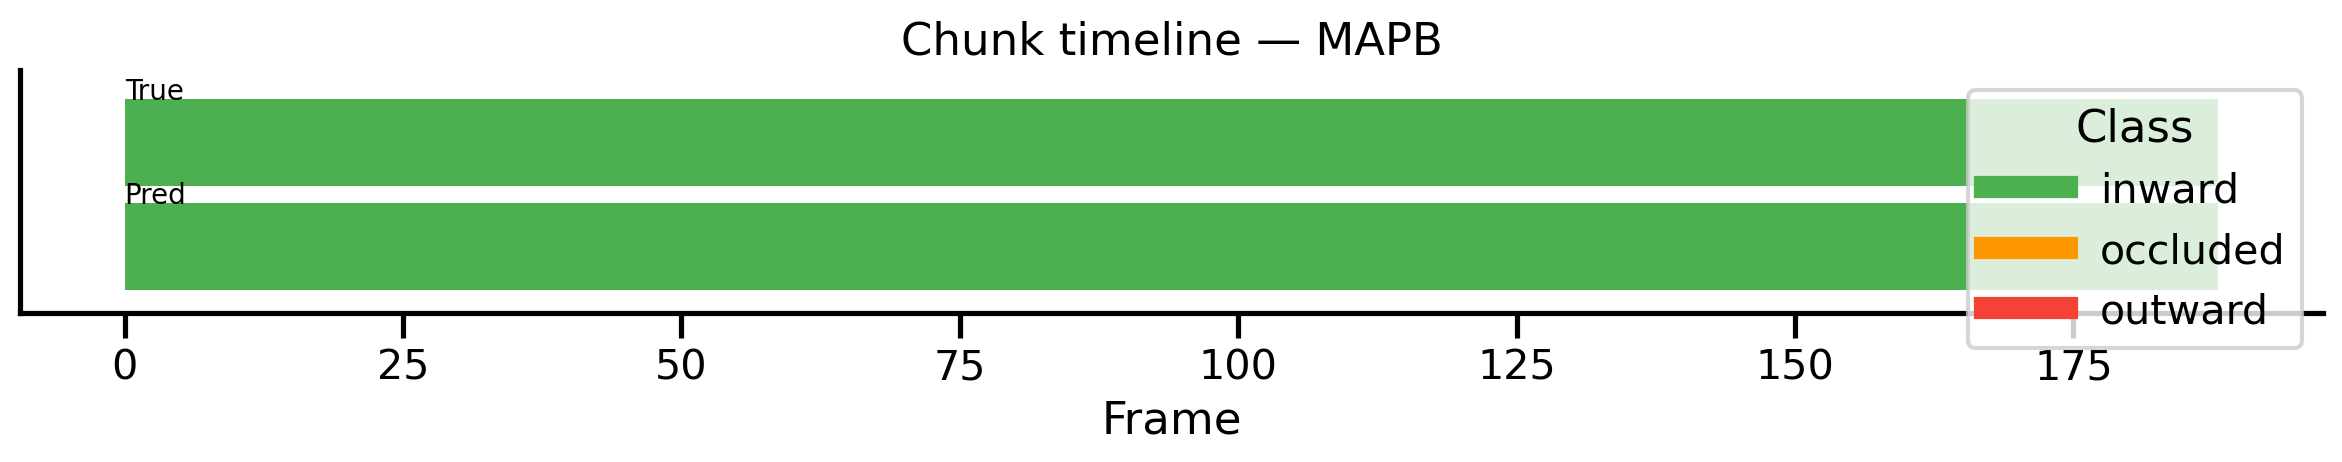

✓ Saved MDMA_20_timeline.png


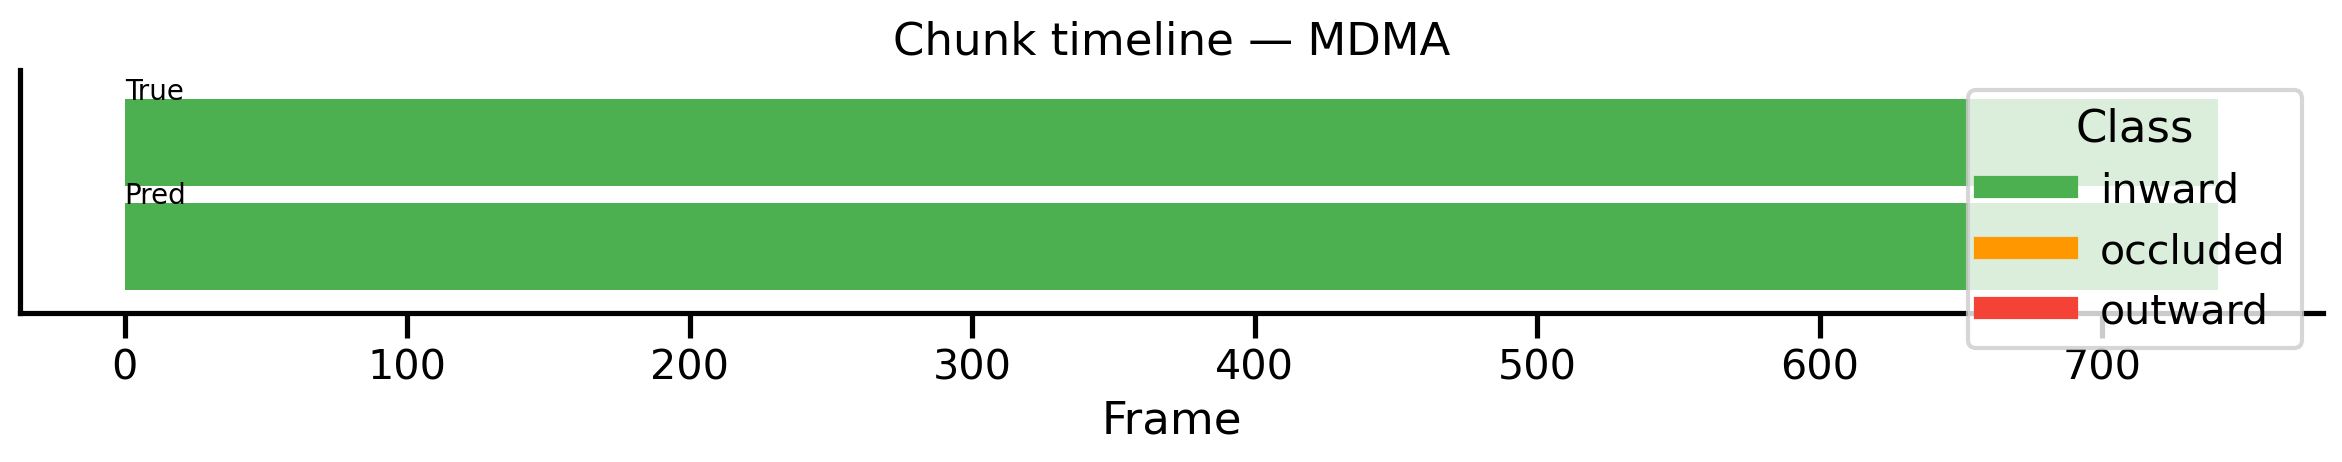

✓ Saved MPH_20_timeline.png


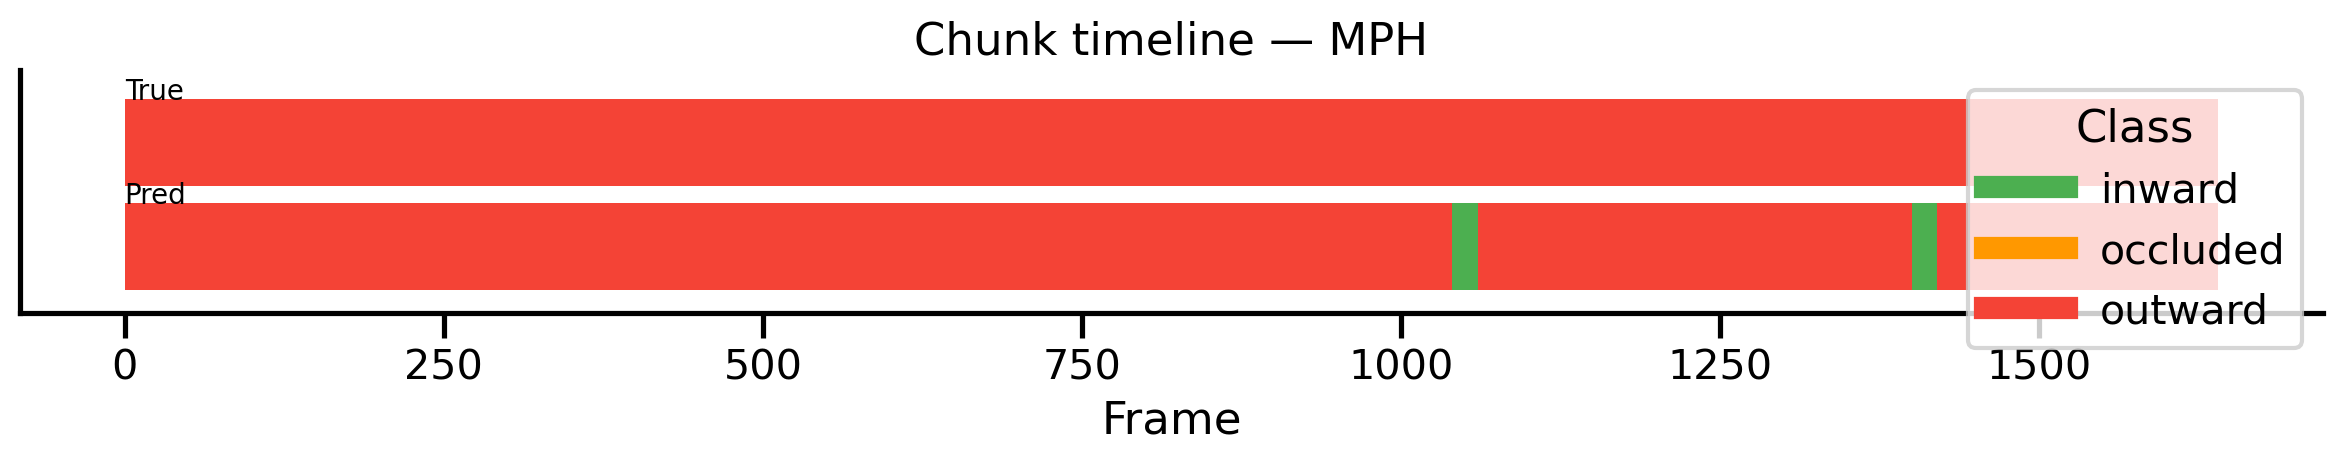

In [8]:
def plot_chunk_timeline(df, savepath=None):
    # Build broken-barh segments for pred and (if present) true
    def segments(labels, color_map):
        segs = []
        if len(labels)==0: return segs
        last = labels.iloc[0]; start = df["start_frame"].iloc[0]
        for i in range(1, len(labels)):
            if labels.iloc[i] != last:
                end = df["end_frame"].iloc[i-1]
                segs.append(((start, end-start+1), {"facecolor": color_map.get(last, "gray")}))
                last = labels.iloc[i]
                start = df["start_frame"].iloc[i]
        end = df["end_frame"].iloc[-1]
        segs.append(((start, end-start+1), {"facecolor": color_map.get(last, "gray")}))
        return segs

    fig, ax = plt.subplots(figsize=(12, 2.6))
    pred_seg = segments(df["pred_class"], CLASS_COLORS)
    for xr, stl in pred_seg: ax.broken_barh([xr], (0.2, 0.75), **stl)
    ax.set_yticks([]); ax.set_xlabel("Frame")
    ttl = f"Chunk timeline — {title_from_name(df['source_file'].iloc[0])}"
    ax.set_title(ttl)

    # Optional true bar if true_class not empty
    if (df["true_class"].astype(str) != "").any():
        true_seg = segments(df["true_class"], CLASS_COLORS)
        for xr, stl in true_seg: ax.broken_barh([xr], (1.1, 0.75), **stl)
        ax.text(df["start_frame"].min(), 1.85, "True", fontsize=10)
        ax.text(df["start_frame"].min(), 0.95, "Pred", fontsize=10)
        ax.set_ylim(0, 2.1)

    # legend
    handles = [plt.Line2D([0],[0], color=c, lw=8) for c in CLASS_COLORS.values()]
    ax.legend(handles, CLASS_COLORS.keys(), title="Class", loc="upper right")
    plt.tight_layout()
    if savepath: savefig(fig, savepath)
    plt.show()

for df in dfs:
    plot_chunk_timeline(df, savepath=FIG_DIR / f"{df['source_file'].iloc[0]}_timeline.png")


## Confidence trend per file (colored by predicted class)

✓ Saved AMP_20_conf_trend.png


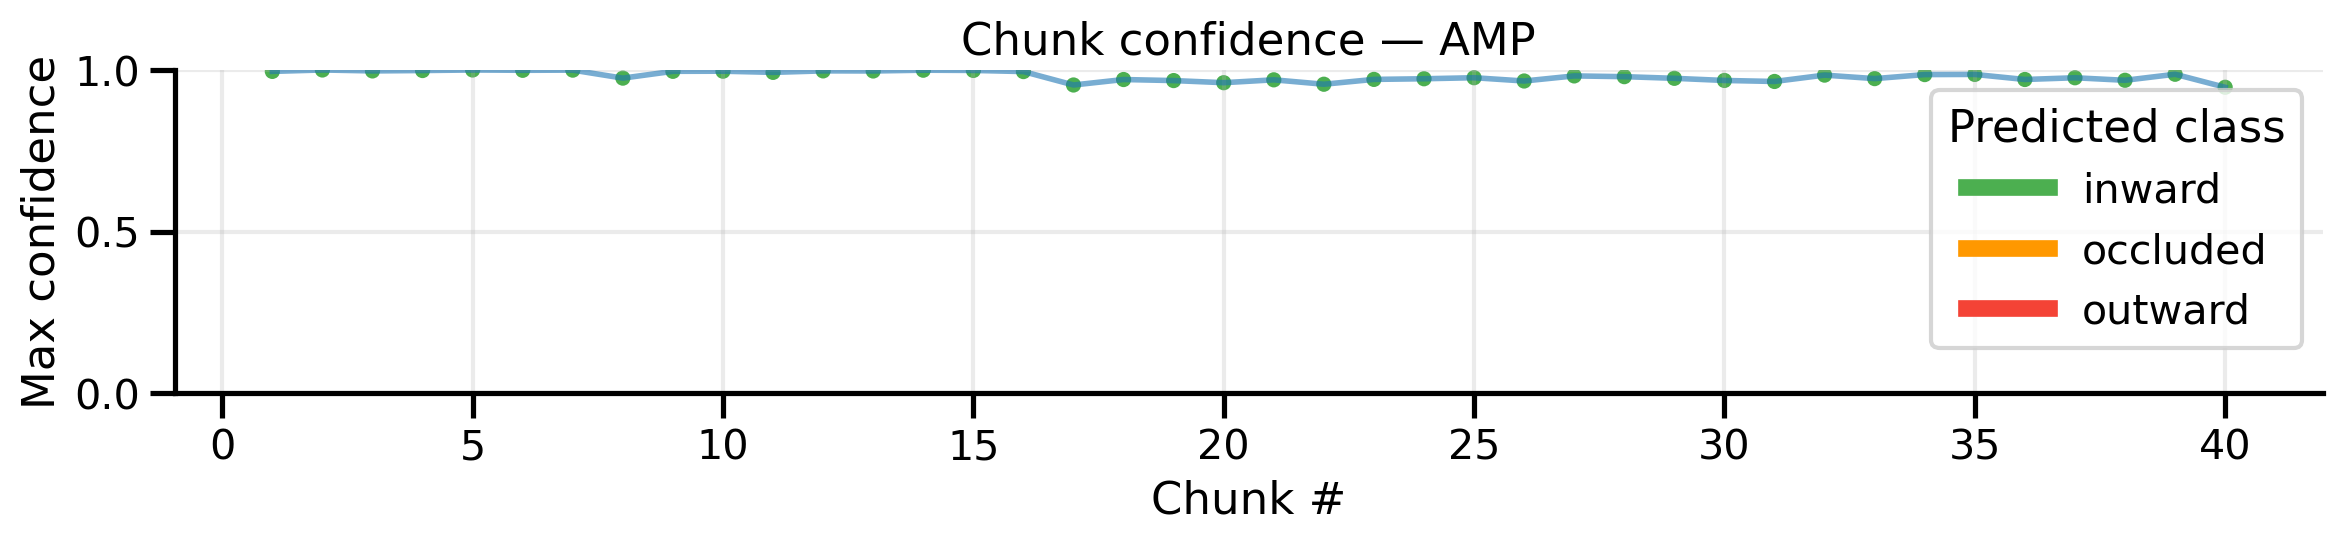

✓ Saved MAPB_20_conf_trend.png


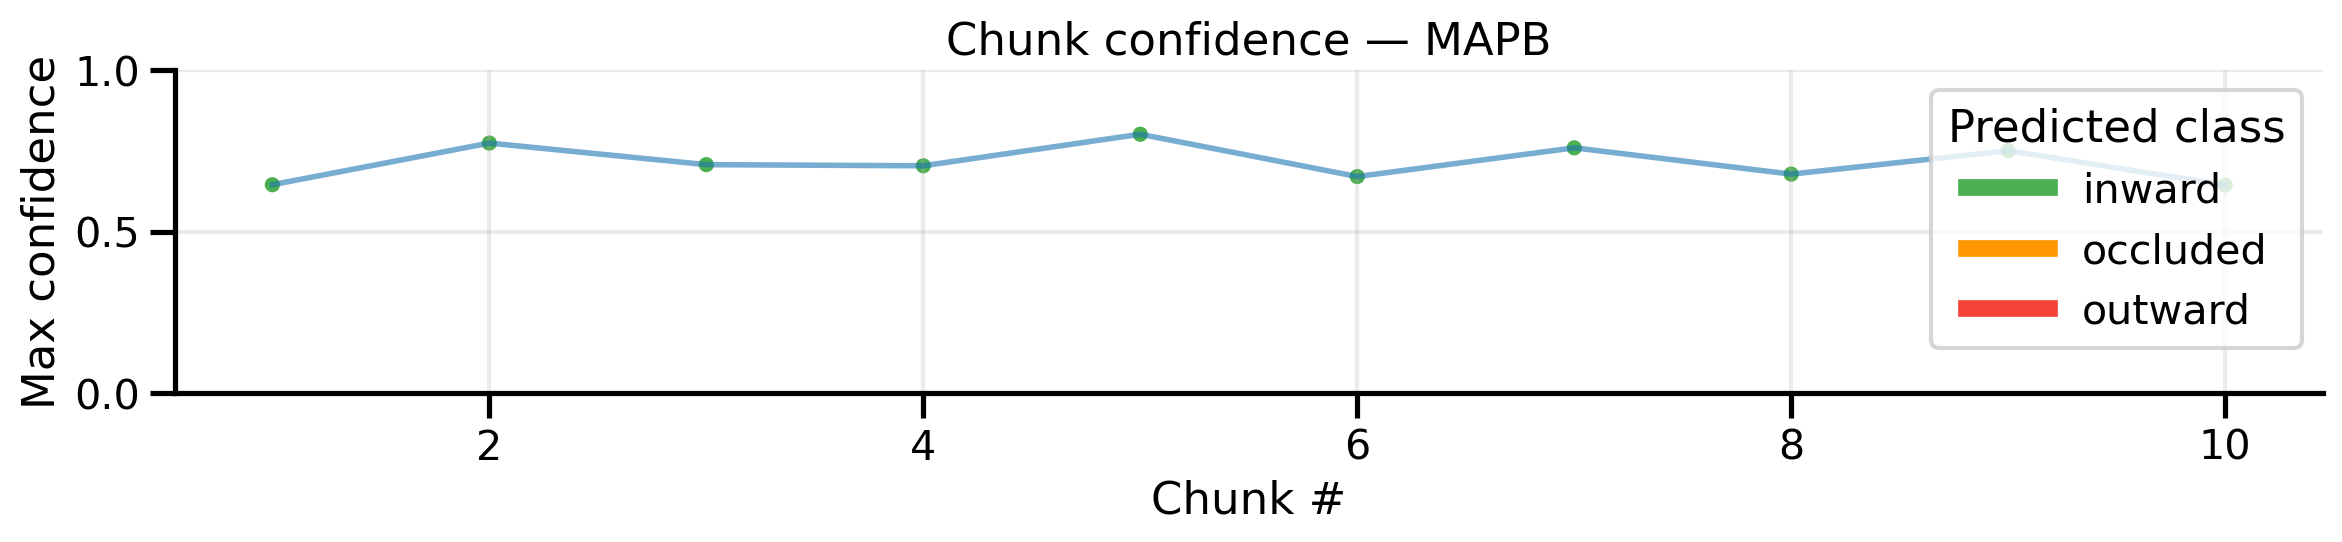

✓ Saved MDMA_20_conf_trend.png


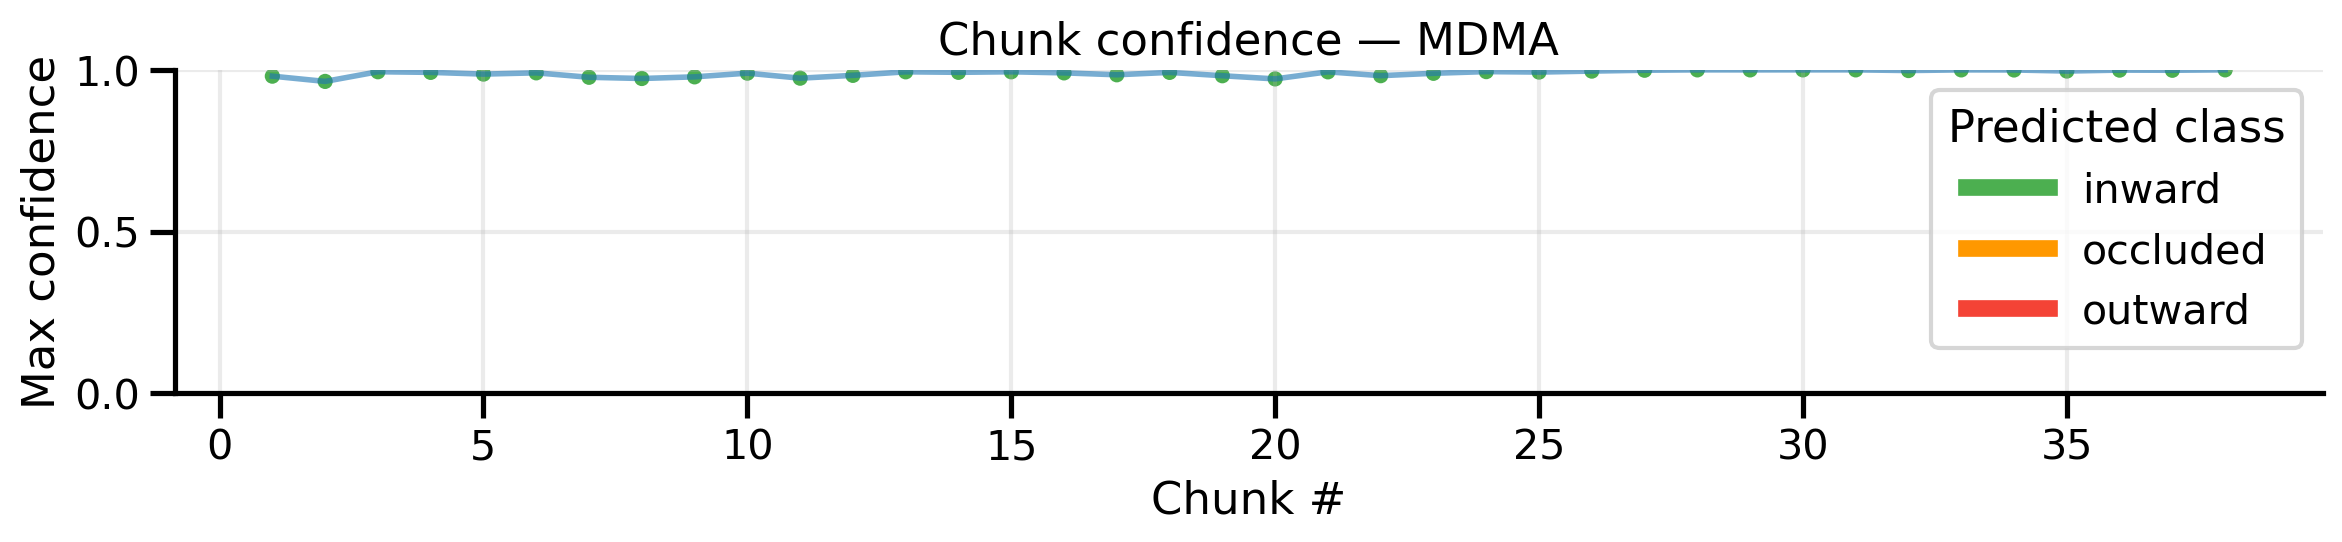

✓ Saved MPH_20_conf_trend.png


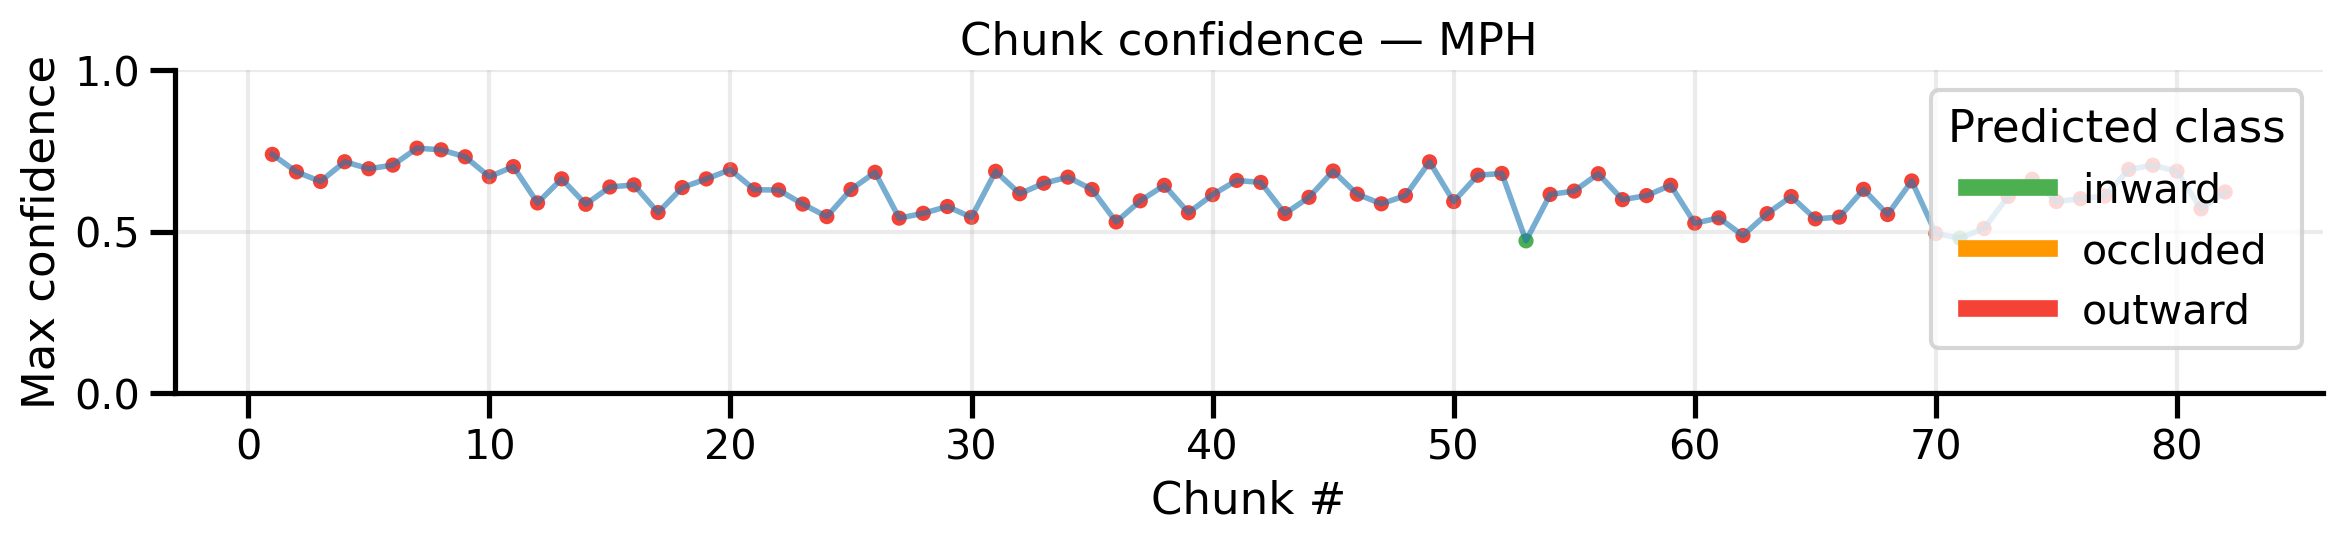

In [9]:
def plot_confidence_trend(df, savepath=None):
    x = df["chunk_id"].values
    y = df["max_conf"].values
    c = df["pred_class"].map(CLASS_COLORS).values

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(x, y, linewidth=2, alpha=.6)
    ax.scatter(x, y, c=c, s=30, edgecolor="none")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Chunk #")
    ax.set_ylabel("Max confidence")
    ax.set_title(f"Chunk confidence — {title_from_name(df['source_file'].iloc[0])}")
    handles = [plt.Line2D([0],[0], color=col, lw=6) for col in CLASS_COLORS.values()]
    ax.legend(handles, CLASS_COLORS.keys(), title="Predicted class", loc="upper right")
    ax.grid(alpha=.25)
    plt.tight_layout()
    if savepath: savefig(fig, savepath)
    plt.show()

for df in dfs:
    plot_confidence_trend(df, savepath=FIG_DIR / f"{df['source_file'].iloc[0]}_conf_trend.png")


##  Confusion matrix

✓ Saved AMP_20_confusion.png


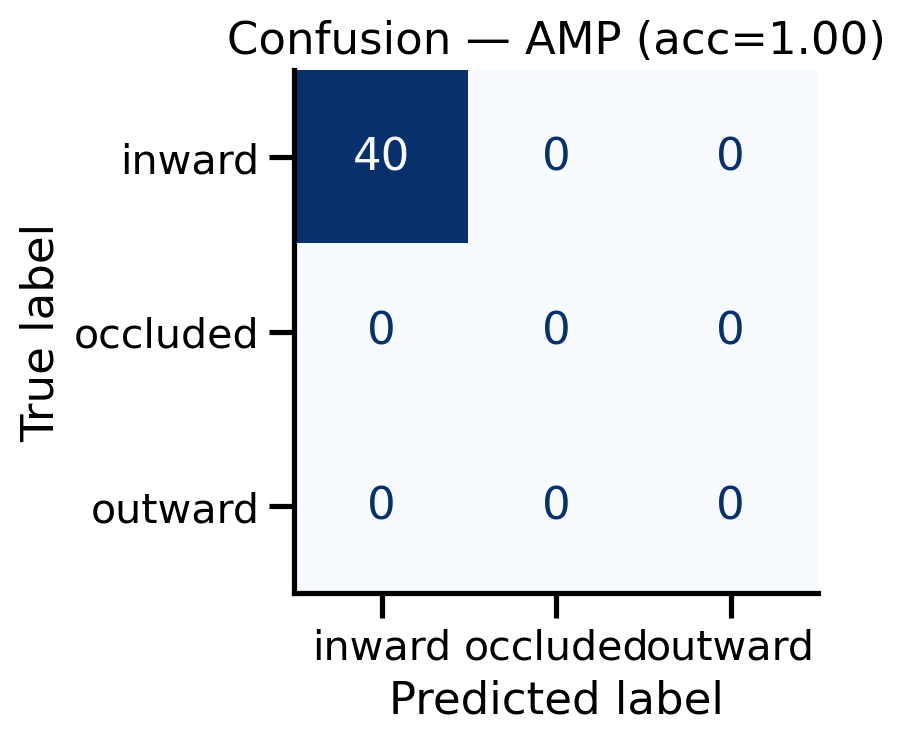

✓ Saved MAPB_20_confusion.png


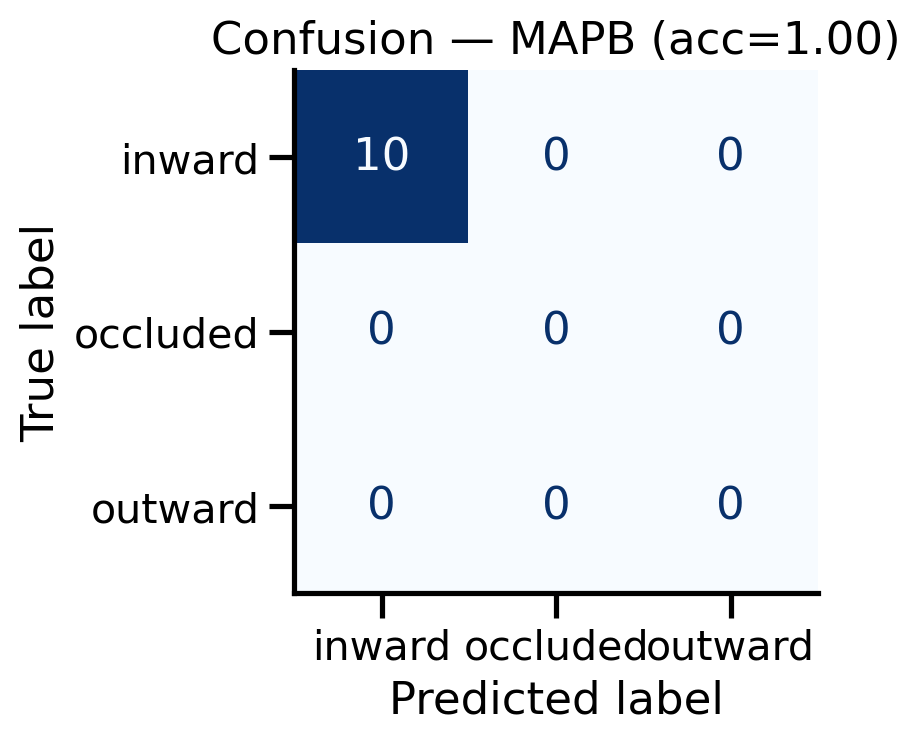

✓ Saved MDMA_20_confusion.png


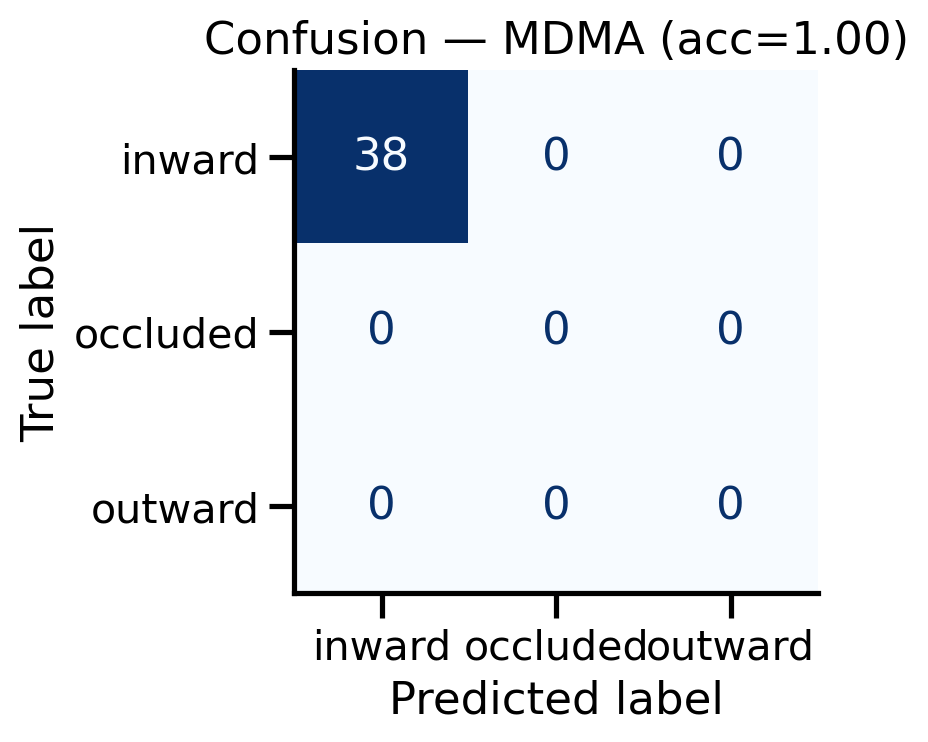

✓ Saved MPH_20_confusion.png


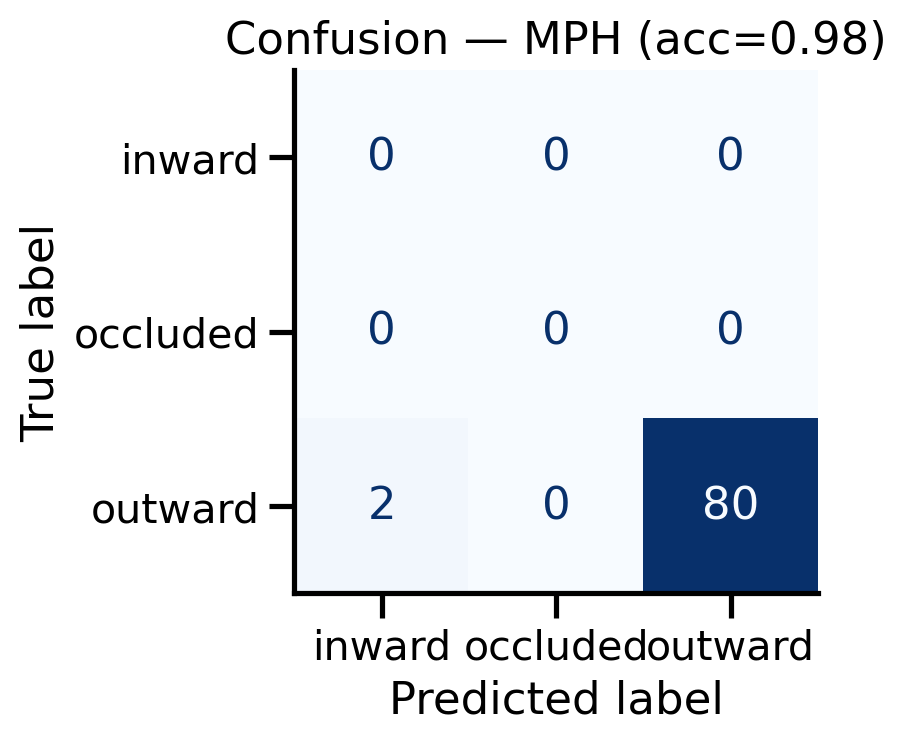

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

def plot_confusion(df, savepath=None):
    if not (df["true_class"].astype(str) != "").any():
        return
    labels = ["inward","occluded","outward"]
    mask = (df["true_class"].astype(str) != "")
    y_true = df.loc[mask, "true_class"].astype(str)
    y_pred = df.loc[mask, "pred_class"].astype(str)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(4.5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"Confusion — {title_from_name(df['source_file'].iloc[0])} (acc={acc:.2f})")
    plt.tight_layout()
    if savepath: savefig(fig, savepath)
    plt.show()

for df in dfs:
    plot_confusion(df, savepath=FIG_DIR / f"{df['source_file'].iloc[0]}_confusion.png")


## Transition counts (per file) + overall

✓ Saved AMP_20_transitions.png


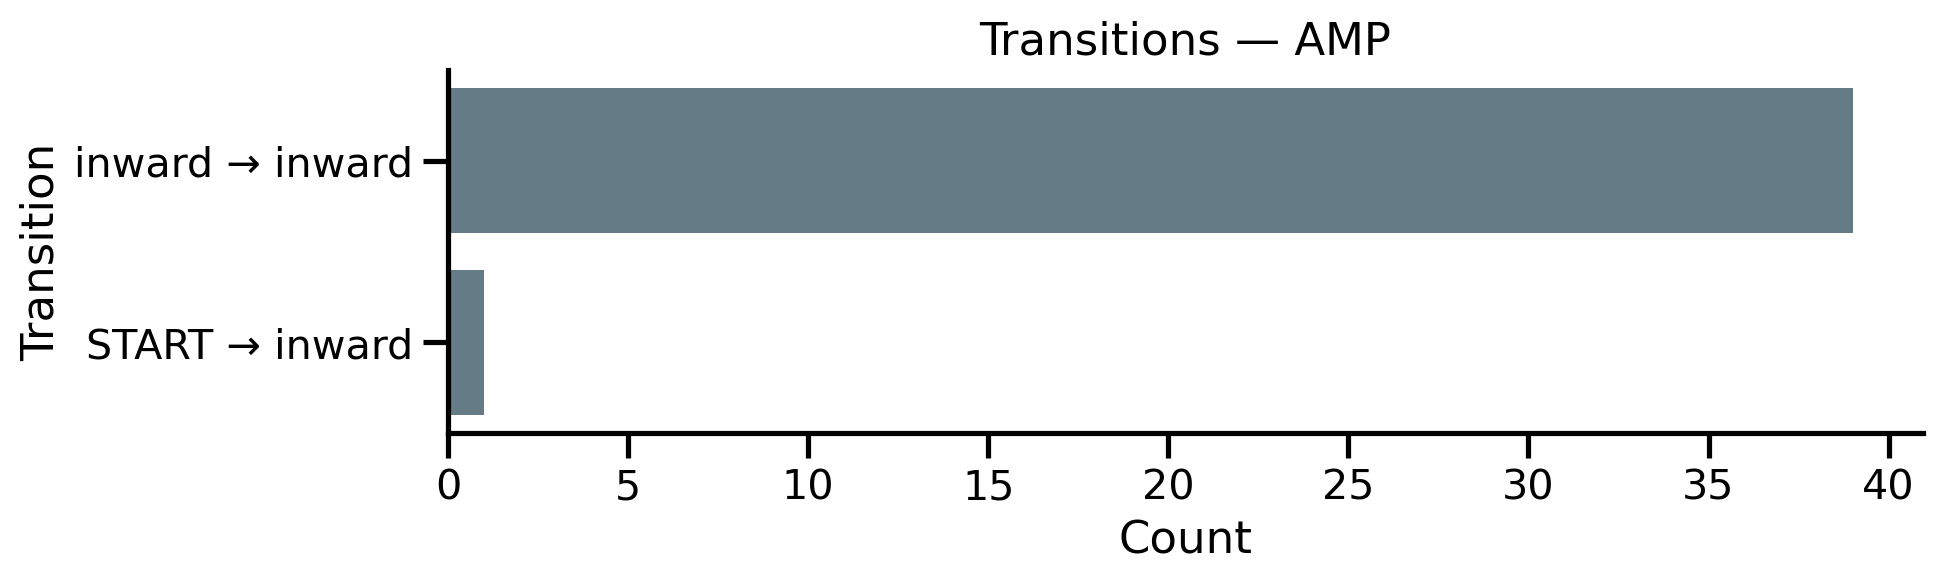

✓ Saved MAPB_20_transitions.png


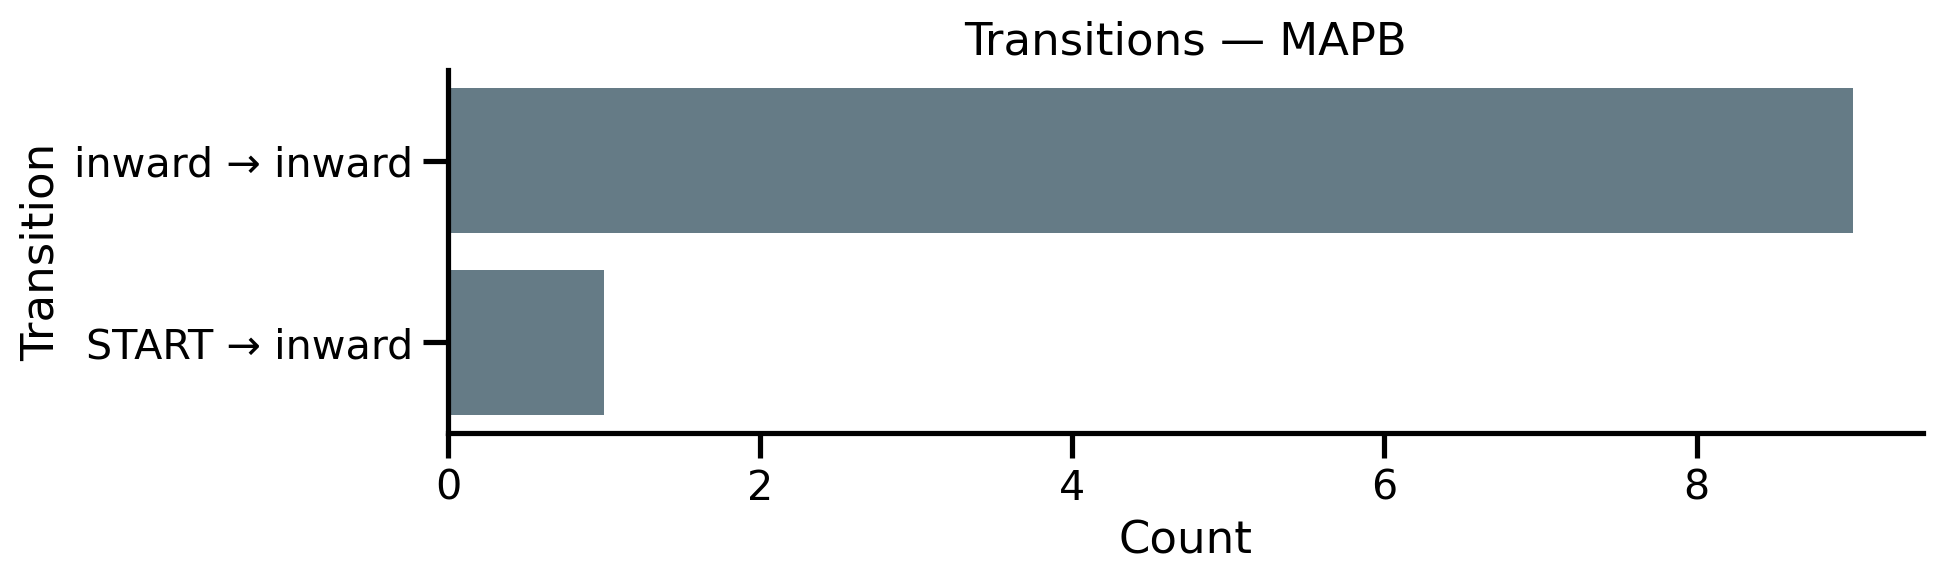

✓ Saved MDMA_20_transitions.png


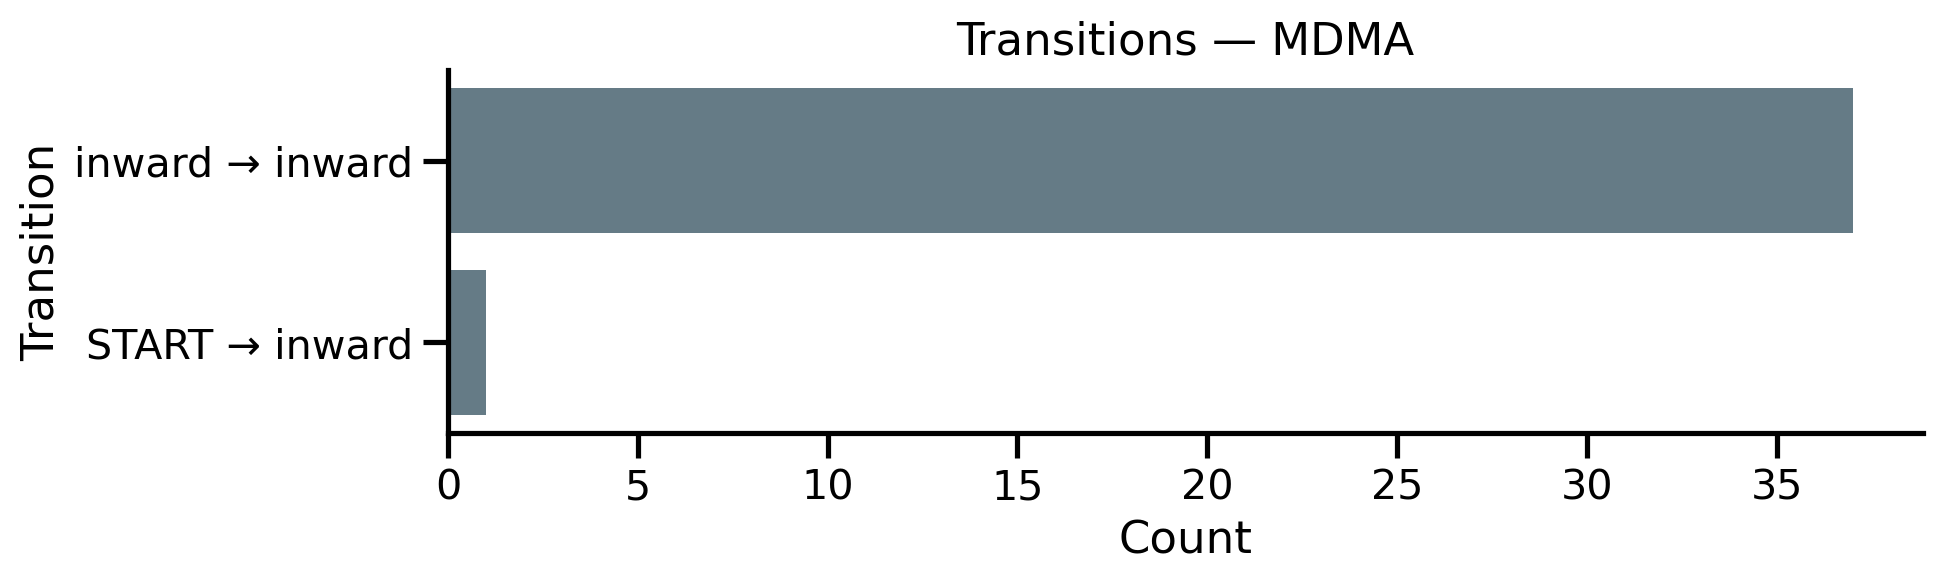

✓ Saved MPH_20_transitions.png


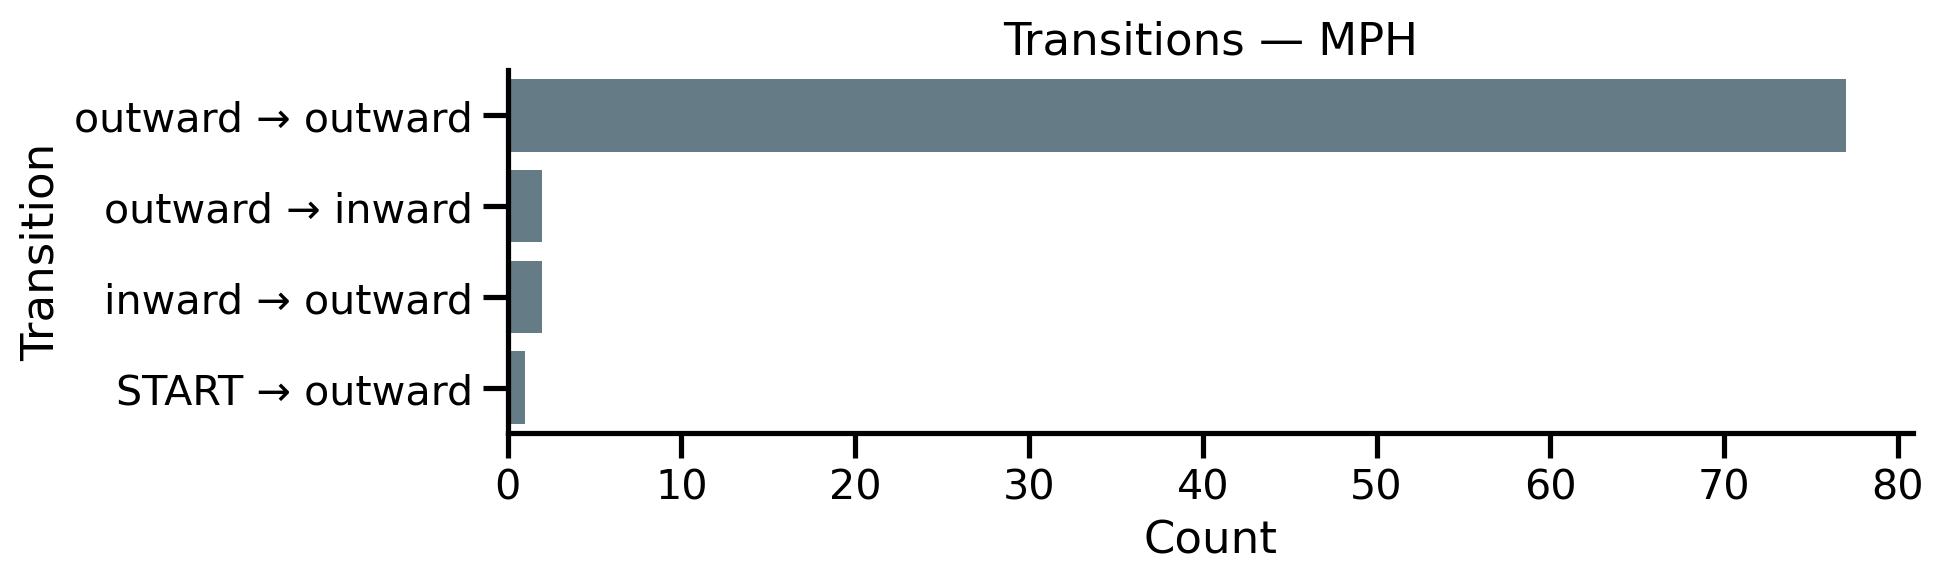

✓ Saved ALL_transitions.png


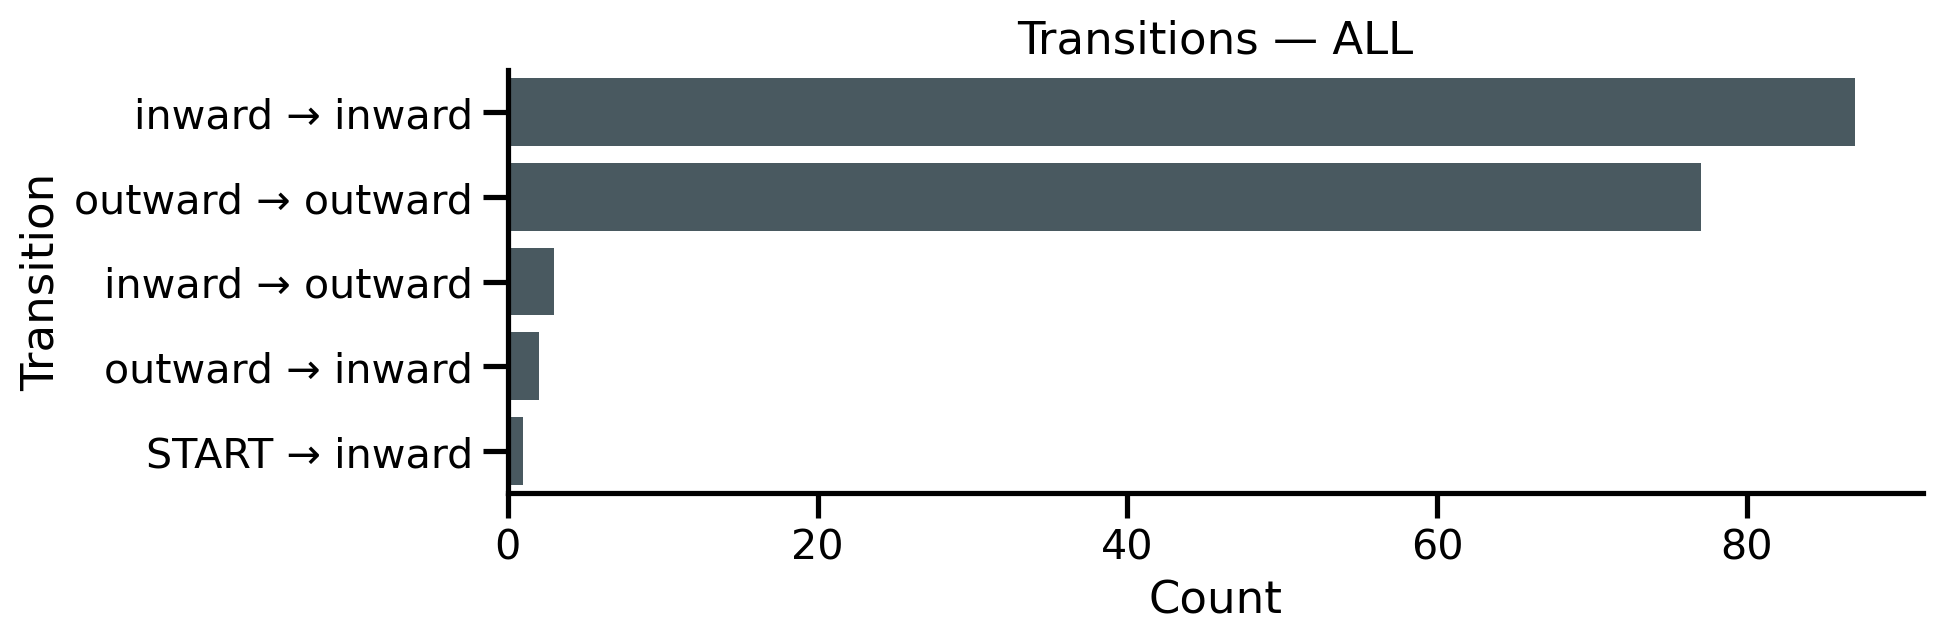

In [11]:
def plot_transitions(df, savepath=None):
    trans = (df["pred_class"].shift(1).fillna("START") + " → " + df["pred_class"]).value_counts()
    fig, ax = plt.subplots(figsize=(10, 3.2))
    sns.barplot(x=trans.values, y=trans.index, ax=ax, color="#607D8B")
    ax.set_xlabel("Count"); ax.set_ylabel("Transition")
    ax.set_title(f"Transitions — {title_from_name(df['source_file'].iloc[0])}")
    plt.tight_layout()
    if savepath: savefig(fig, savepath)
    plt.show()

for df in dfs:
    plot_transitions(df, savepath=FIG_DIR / f"{df['source_file'].iloc[0]}_transitions.png")

# Overall transitions across all files
if dfs:
    big = pd.concat(dfs, ignore_index=True)
    trans_all = (big["pred_class"].shift(1).fillna("START") + " → " + big["pred_class"]).value_counts()
    fig, ax = plt.subplots(figsize=(10, 3.5))
    sns.barplot(x=trans_all.values, y=trans_all.index, ax=ax, color="#455A64")
    ax.set_xlabel("Count"); ax.set_ylabel("Transition"); ax.set_title("Transitions — ALL")
    plt.tight_layout()
    savefig(fig, FIG_DIR / "ALL_transitions.png")
    plt.show()


## Confidence distribution by class (overall)

✓ Saved ALL_conf_by_class.png


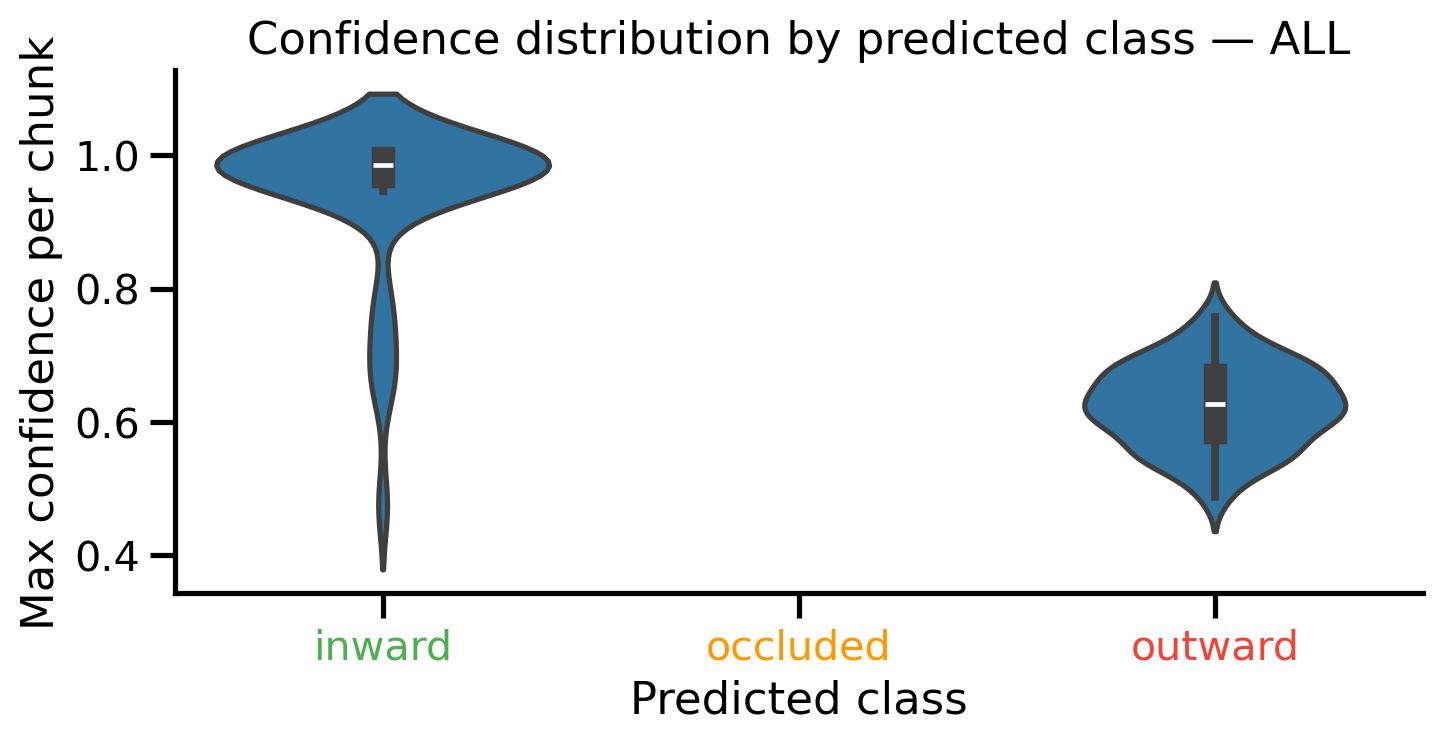

In [12]:
if dfs:
    big = pd.concat(dfs, ignore_index=True)
    fig, ax = plt.subplots(figsize=(7.5, 4))
    order = ["inward","occluded","outward"]
    sns.violinplot(data=big, x="pred_class", y="max_conf", order=order, inner="box")
    ax.set_xlabel("Predicted class"); ax.set_ylabel("Max confidence per chunk")
    ax.set_title("Confidence distribution by predicted class — ALL")
    for tick in ax.get_xticklabels():
        tick.set_color(CLASS_COLORS.get(tick.get_text(), "black"))
    plt.tight_layout()
    savefig(fig, FIG_DIR / "ALL_conf_by_class.png")
    plt.show()


## line graph

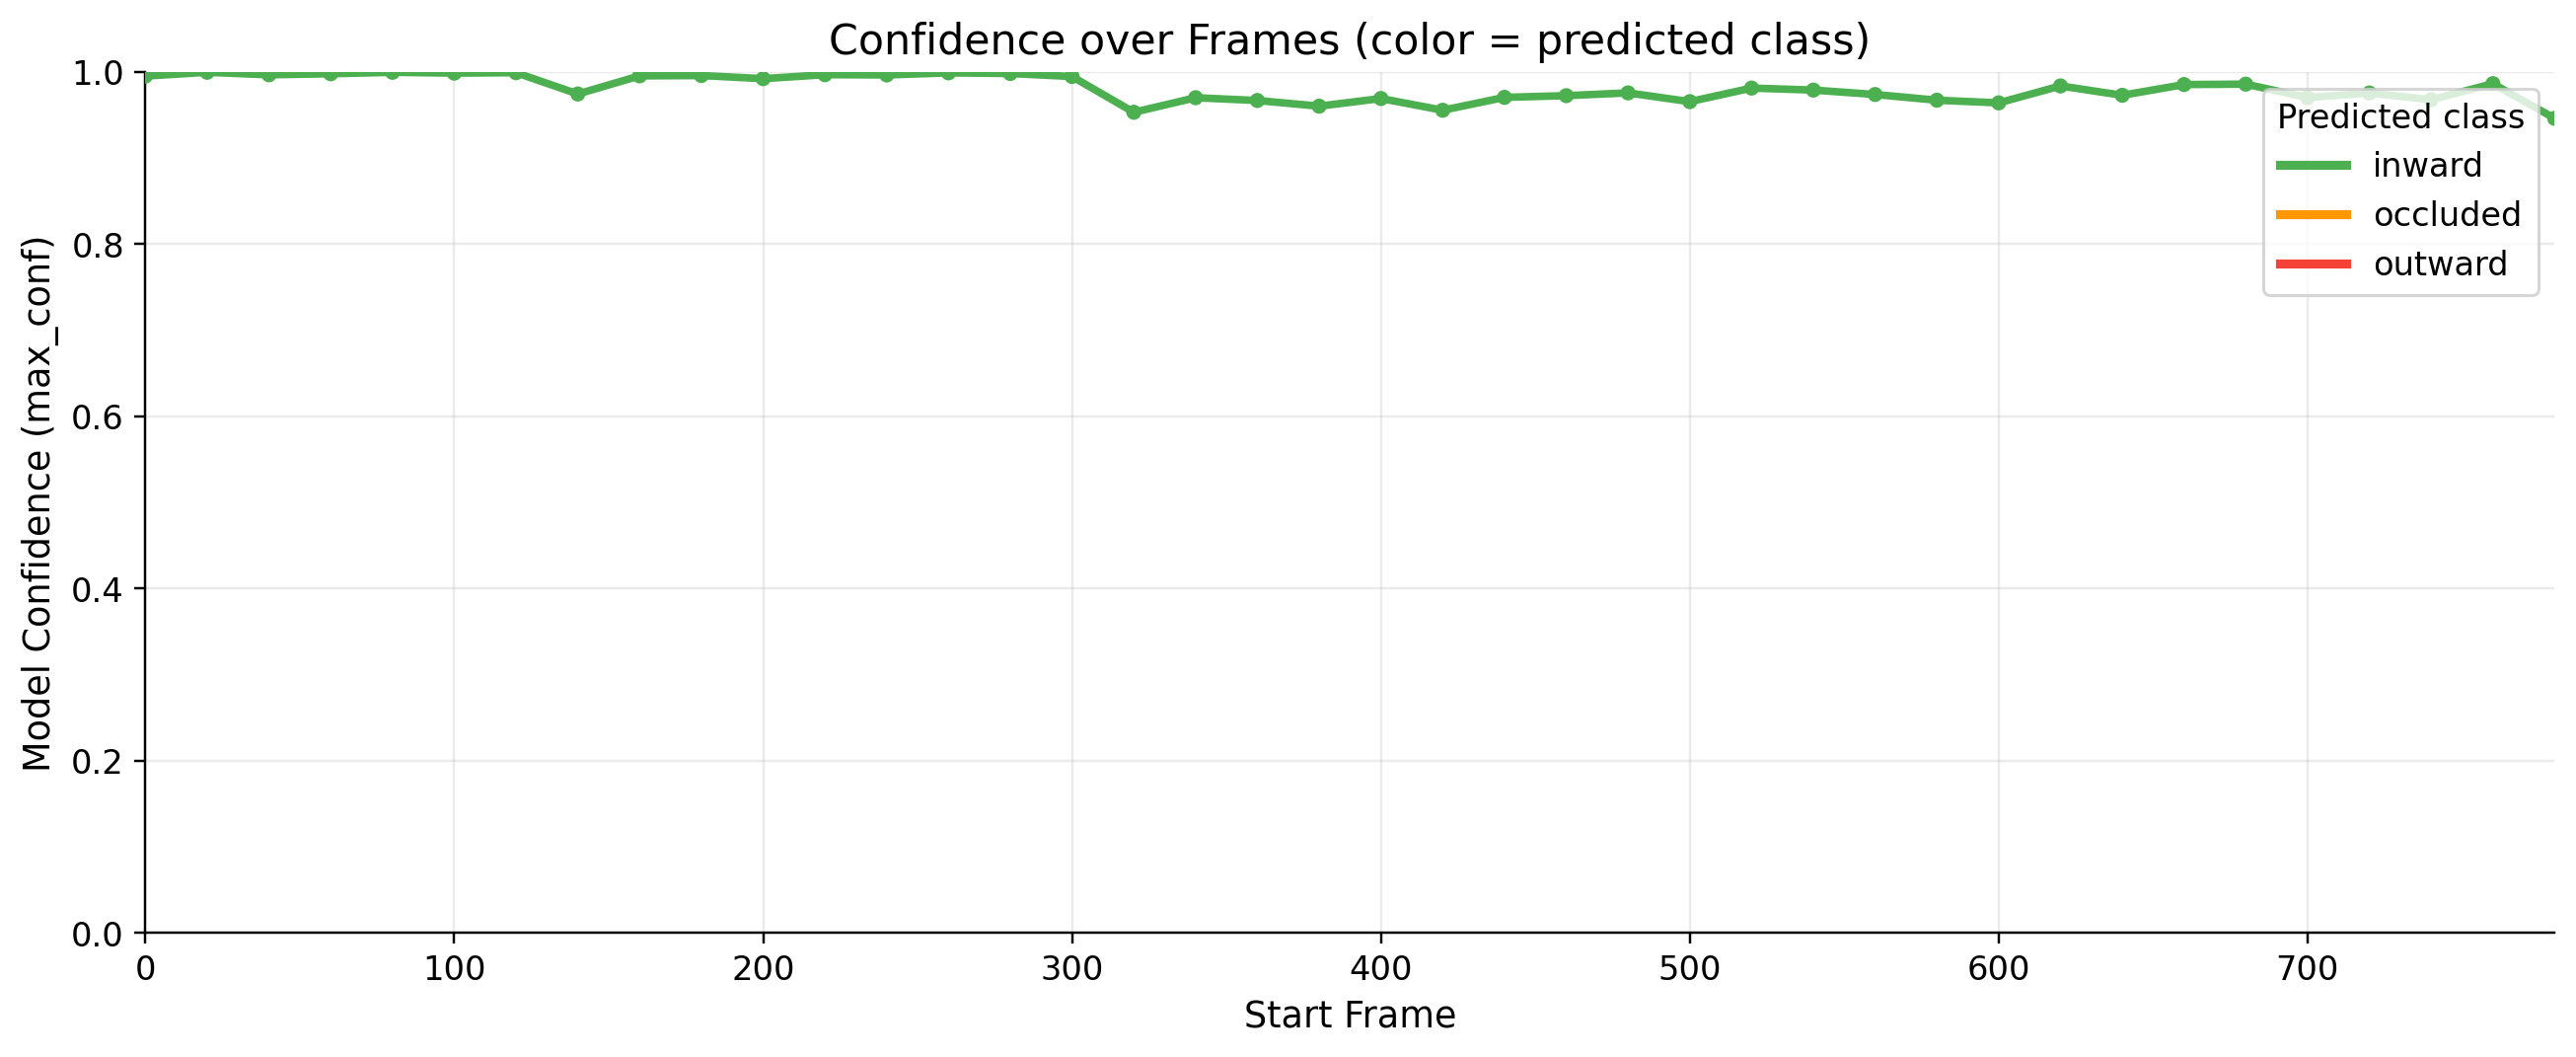

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# Load your CSV (replace with your file path)
csv_path = r"D:/Coding Projects/AI-in-Drug-Discovery-/presentation_figs/V5_Data/AMP_20.csv"
df = pd.read_csv(csv_path)

# --- Keep only what we need and sort by frame ---
df = df[["start_frame", "max_conf", "pred_class"]].sort_values("start_frame").reset_index(drop=True)

# --- Class colors ---
CLASS_COLORS = {"inward": "#4CAF50", "occluded": "#FF9800", "outward": "#F44336"}

# --- Build the line as colored segments ---
x = df["start_frame"].to_numpy(float)
y = df["max_conf"].to_numpy(float)
labels = df["pred_class"].astype(str).to_numpy()

# points -> segments between consecutive points
points = np.column_stack([x, y]).reshape(-1, 1, 2)              # (N, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)    # (N-1, 2, 2)

# color each segment by the class at its start
seg_colors = [CLASS_COLORS.get(lbl, "black") for lbl in labels[:-1]]

fig, ax = plt.subplots(figsize=(12, 5))

lc = LineCollection(segments, colors=seg_colors, linewidths=2.5)
ax.add_collection(lc)

# also plot the points (optional, small markers) colored by class
ax.scatter(x, y, s=16, c=[CLASS_COLORS.get(lbl, "black") for lbl in labels], zorder=3)

# axes/limits/labels
ax.set_xlim(x.min(), x.max())
ax.set_ylim(0, 1)
ax.set_xlabel("Start Frame", fontsize=12)
ax.set_ylabel("Model Confidence (max_conf)", fontsize=12)
ax.set_title("Confidence over Frames (color = predicted class)", fontsize=14)

# optional: light grid + vertical lines where class changes
change_idx = np.where(labels[1:] != labels[:-1])[0] + 1
for idx in change_idx:
    ax.axvline(x[idx], color="#9E9E9E", lw=0.8, ls="--", alpha=0.6)

ax.grid(alpha=0.25)

# legend (dummy handles using the same colors)
handles = [plt.Line2D([0],[0], color=c, lw=3) for c in CLASS_COLORS.values()]
ax.legend(handles, CLASS_COLORS.keys(), title="Predicted class", loc="upper right")

plt.tight_layout()
plt.show()

## Summary table (for a slide)

In [13]:
def build_summary(dfs):
    rows = []
    for df in dfs:
        name = title_from_name(df["source_file"].iloc[0])
        n = len(df)
        mean_conf = df["max_conf"].mean()
        frac = df["pred_class"].value_counts(normalize=True)
        rows.append({
            "file": name,
            "n_chunks": n,
            "mean_conf": round(mean_conf, 3),
            "pct_inward":  round(frac.get("inward", 0.0), 3),
            "pct_occluded":round(frac.get("occluded", 0.0), 3),
            "pct_outward": round(frac.get("outward", 0.0), 3),
        })
    return pd.DataFrame(rows).sort_values("file")

if dfs:
    summary = build_summary(dfs)
    display(summary)
    summary.to_csv(FIG_DIR / "summary_table.csv", index=False)
    print("✓ Saved summary_table.csv")


,file,n_chunks,mean_conf,pct_inward,pct_occluded,pct_outward
0,AMP,40,0.981,1.000,0.0,0.000
1,MAPB,10,0.713,1.000,0.0,0.000
2,MDMA,38,0.990,1.000,0.0,0.000
3,MPH,82,0.621,0.024,0.0,0.976


✓ Saved summary_table.csv


## Slide 4

Saved infographic: presentation_figs\slide4_split_infographic.png


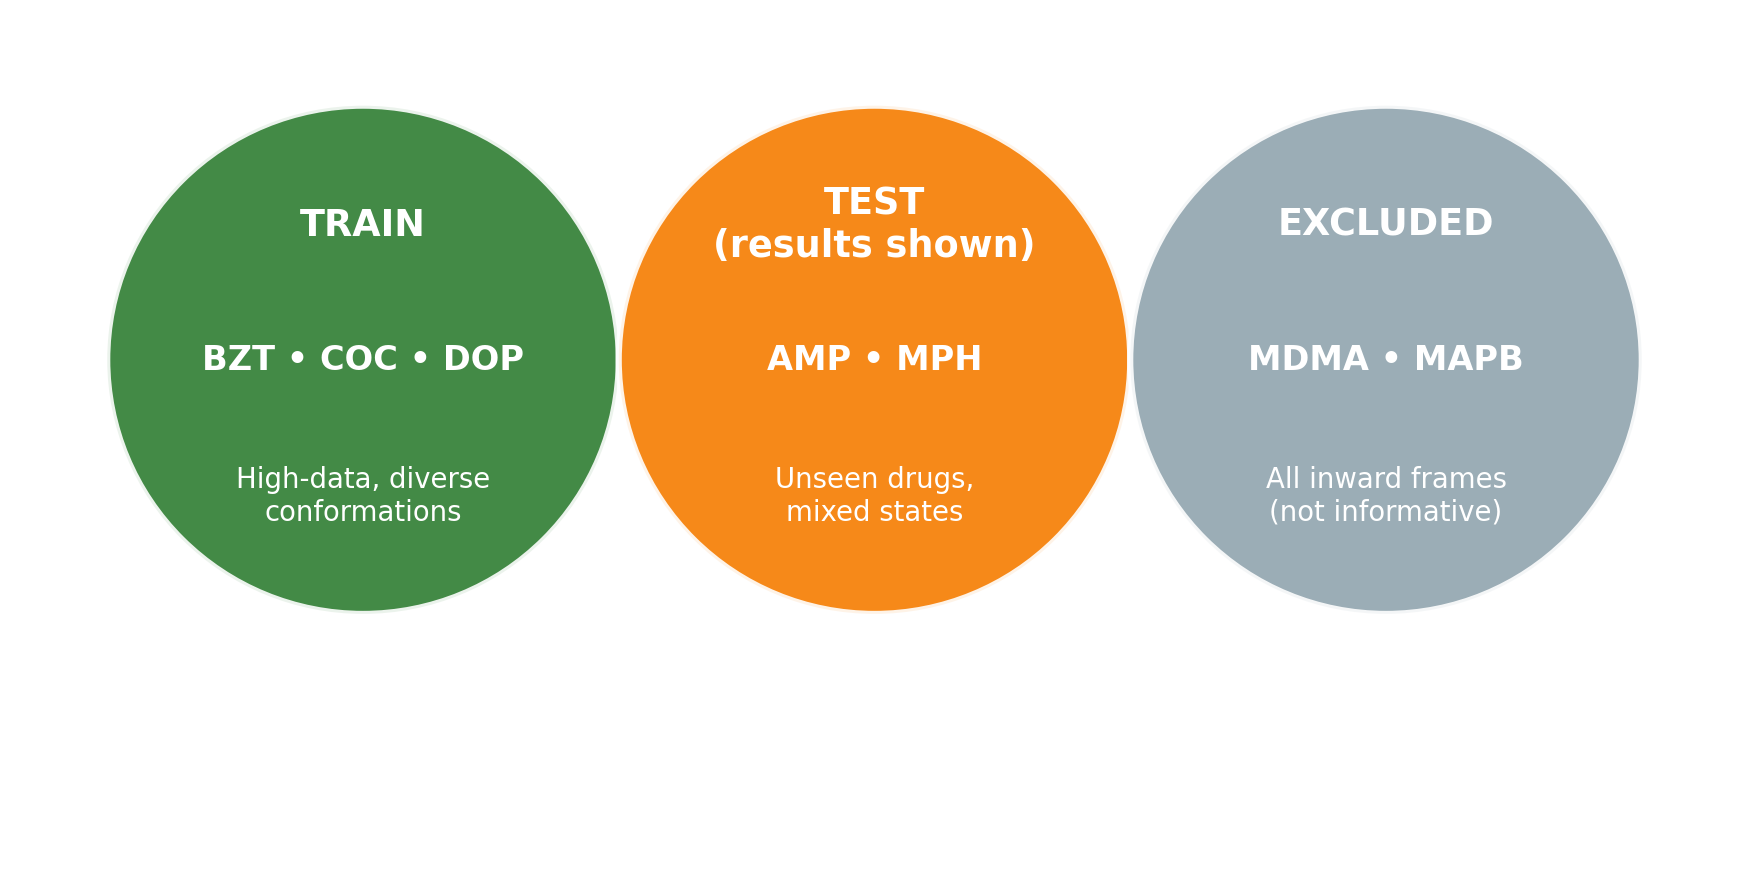

In [11]:
# slide4_split_infographic.py
# Creates: presentation_figs/slide4_split_infographic.png

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# ---- OUTPUT PATH ----
OUT_DIR = Path("presentation_figs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "slide4_split_infographic.png"

# ---- COLORS ----
train_color = "#2E7D32"
test_color = "#F57C00"
exclude_color = "#90A4AE"

# ---- FIGURE ----
plt.rcParams.update({"figure.dpi": 220, "font.size": 11})
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

# Circle positions
positions = [(2, 3), (5, 3), (8, 3)]
labels = ["TRAIN", "TEST\n(results shown)", "EXCLUDED"]
drugs = [
    "BZT • COC • DOP",
    "AMP • MPH",
    "MDMA • MAPB"
]
reasons = [
    "High-data, diverse\nconformations",
    "Unseen drugs,\nmixed states",
    "All inward frames\n(not informative)"
]
colors = [train_color, test_color, exclude_color]

# Draw circles and text
for (x, y), label, drug, reason, col in zip(positions, labels, drugs, reasons, colors):
    circ = Circle((x, y), radius=1.5, facecolor=col, alpha=0.9, edgecolor="white", lw=2)
    ax.add_patch(circ)
    ax.text(x, y+0.8, label, ha="center", va="center", color="white", fontsize=12, weight="bold")
    ax.text(x, y, drug, ha="center", va="center", color="white", fontsize=11, weight="bold")
    ax.text(x, y-0.8, reason, ha="center", va="center", color="white", fontsize=9, linespacing=1.2)


# Save
fig.savefig(OUT_PNG, bbox_inches="tight", facecolor="white")
print(f"Saved infographic: {OUT_PNG}")


## prove of the selected datasets

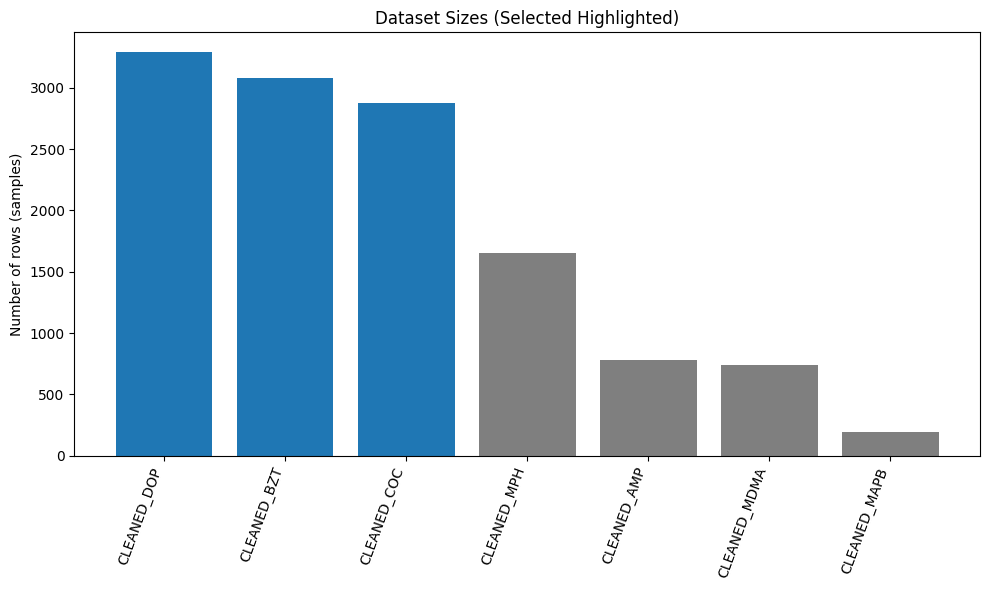

We prioritised datasets by sample size to improve generalisation and reduce overfitting. The three selected datasets (BZT/COC/DOP) contained a median of 3084 samples, compared to 762 in the remaining datasets. A one-sided Mann–Whitney U test indicated the selected datasets were larger than the others (U=12.0, p=0.02857). Effect size (Cliff's delta) was 1.000 (large).


In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# --- CONFIG ---
DATA_DIR = r"D:/Coding Projects/AI-in-Drug-Discovery-/presentation_figs/V5_Data/org_data"
SELECTED_TOKENS = {"BZT", "COC", "DOP"}  # Marked as your chosen datasets

# --- HELPERS ---
def infer_dataset_name(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    return re.sub(r"[^A-Za-z0-9_-]", "", stem).upper()

def is_selected(name):
    return any(tok in name for tok in SELECTED_TOKENS)

def fast_row_count(path):
    with open(path, 'rb') as f:
        count = 0
        buf = f.read(1024 * 1024)
        while buf:
            count += buf.count(b'\n')
            buf = f.read(1024 * 1024)
    return max(count - 1, 0)

def cliffs_delta(x, y):
    n1, n2 = len(x), len(y)
    greater = sum(1 for xi in x for yj in y if xi > yj)
    lesser = sum(1 for xi in x for yj in y if xi < yj)
    return (greater - lesser) / (n1 * n2) if n1 and n2 else np.nan

def interpret_delta(delta):
    if np.isnan(delta):
        return "N/A"
    ad = abs(delta)
    if ad < 0.147: return "negligible"
    if ad < 0.33: return "small"
    if ad < 0.474: return "medium"
    return "large"

# --- LOAD DATA ---
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
records = [{"dataset": infer_dataset_name(f),
            "rows": fast_row_count(f),
            "selected": is_selected(infer_dataset_name(f))}
           for f in csv_files]

sizes_df = pd.DataFrame(records).sort_values("rows", ascending=False).reset_index(drop=True)

# --- SPLIT ---
chosen = sizes_df[sizes_df["selected"]]["rows"].to_numpy()
others = sizes_df[~sizes_df["selected"]]["rows"].to_numpy()

# --- STATS ---
U, p_value = (np.nan, np.nan)
if len(others):
    U, p_value = mannwhitneyu(chosen, others, alternative='greater')
delta = cliffs_delta(chosen, others)
effect_label = interpret_delta(delta)

# --- PLOT ---
plt.figure(figsize=(10, 6))
order = sizes_df.sort_values("rows", ascending=False).reset_index(drop=True)
colors = ["tab:blue" if sel else "tab:gray" for sel in order["selected"]]
plt.bar(order["dataset"], order["rows"], color=colors)
plt.xticks(rotation=70, ha='right')
plt.ylabel("Number of rows (samples)")
plt.title("Dataset Sizes (Selected Highlighted)")
plt.tight_layout()
plt.show()

# --- SUMMARY SENTENCE ---
chosen_med = np.median(chosen) if len(chosen) else np.nan
others_med = np.median(others) if len(others) else np.nan

fmt = lambda x: "N/A" if (isinstance(x, float) and np.isnan(x)) else f"{int(x)}"
summary_sentence = (
    "We prioritised datasets by sample size to improve generalisation and reduce overfitting. "
    f"The three selected datasets (BZT/COC/DOP) contained a median of {fmt(chosen_med)} samples, "
    f"compared to {fmt(others_med)} in the remaining datasets. "
    "A one-sided Mann–Whitney U test indicated the selected datasets were larger than the others "
    f"(U={U}, p={'{:.4g}'.format(p_value) if not np.isnan(p_value) else 'N/A'}). "
    f"Effect size (Cliff's delta) was {delta:.3f} ({effect_label})."
)

print(summary_sentence)
